In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("=" * 50)
print("FAKE NEWS DETECTION - COMPLETE PIPELINE")
print("=" * 50)

FAKE NEWS DETECTION - COMPLETE PIPELINE


In [2]:
if not os.path.exists("train.csv") or not os.path.exists("test.csv"):
    print("Running preprocessing...")
    
    fake_df = pd.read_csv("Fake.csv")
    true_df = pd.read_csv("True.csv")
    
    fake_df['label'] = 'FAKE'
    true_df['label'] = 'REAL'
    
    df = pd.concat([fake_df, true_df], axis=0, ignore_index=True)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    df['content'] = df['title'] + " " + df['text']
    df['date'] = pd.to_datetime(df['date'])
    
    split_idx = int(0.8 * len(df))
    train = df[:split_idx]
    test = df[split_idx:]
    
    train.to_csv("train.csv", index=False)
    test.to_csv("test.csv", index=False)
    print(f"Preprocessing complete: {len(train)} train, {len(test)} test samples")
else:
    print("Preprocessed data found. Loading...")

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Preprocessed data found. Loading...
Train shape: (34350, 7), Test shape: (8588, 7)


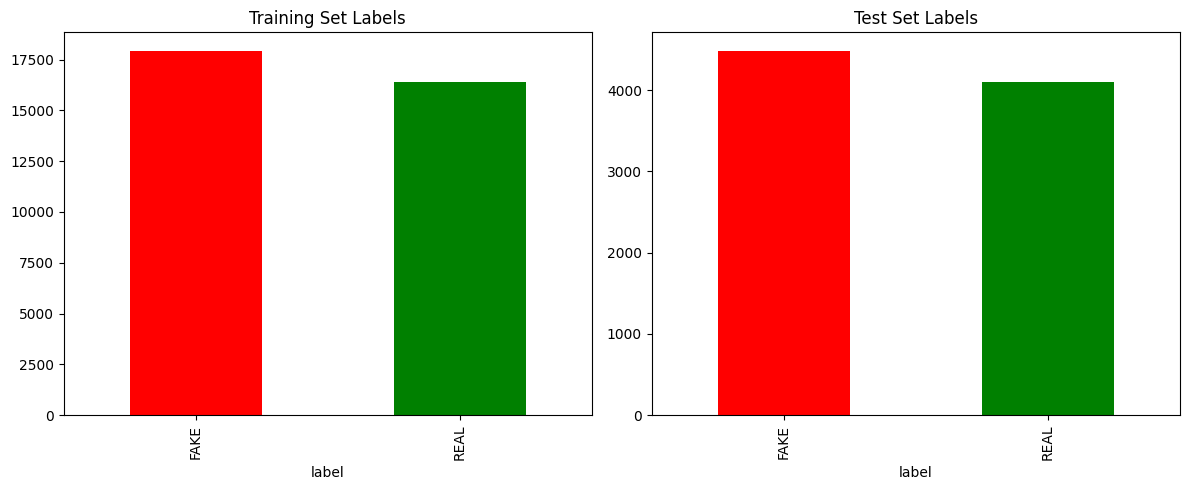

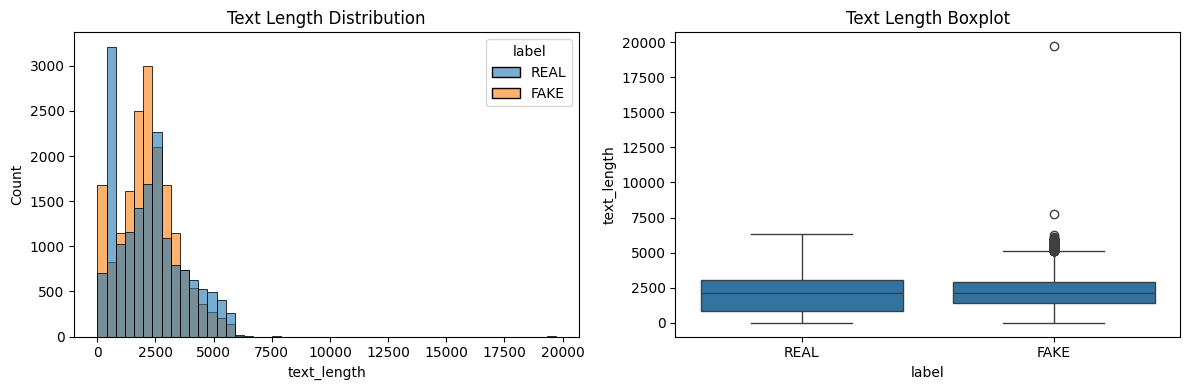

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

train['label'].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'green'], title='Training Set Labels')
test['label'].value_counts().plot(kind='bar', ax=axes[1], color=['red', 'green'], title='Test Set Labels')
plt.tight_layout()
plt.show()

train['text_length'] = train['text'].str.len()
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(data=train, x='text_length', hue='label', bins=50, alpha=0.6)
plt.title('Text Length Distribution')
plt.subplot(1, 2, 2)
sns.boxplot(data=train, x='label', y='text_length')
plt.title('Text Length Boxplot')
plt.tight_layout()
plt.show()

In [4]:
X_train_text = train["content"]
y_train = train["label"]
X_test_text = test["content"]
y_test = test["label"]

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8, stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print(f"TF-IDF shape - Train: {X_train_tfidf.shape}, Test: {X_test_tfidf.shape}")

TF-IDF shape - Train: (34350, 5000), Test: (8588, 5000)


In [6]:
# Train the model
model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)
print("Model training complete!")

Model training complete!


In [7]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='FAKE')
recall = recall_score(y_test, y_pred, pos_label='FAKE')
f1 = f1_score(y_test, y_pred, pos_label='FAKE')

print("\n" + "=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


MODEL PERFORMANCE METRICS
Accuracy:  0.9907 (99.07%)
Precision: 0.9931
Recall:    0.9891
F1-Score:  0.9911


In [8]:
joblib.dump(model, 'logistic_regression_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [9]:
cm = confusion_matrix(y_test, y_pred, labels=['FAKE', 'REAL'])

print("\nConfusion Matrix:")
print("              PREDICTED")
print("              FAKE   REAL")
print(f"ACTUAL FAKE   {cm[0][0]:5d}  {cm[0][1]:5d}")
print(f"       REAL   {cm[1][0]:5d}  {cm[1][1]:5d}")

print("\nInterpretation:")
print(f"  True Positives (correctly predicted FAKE):  {cm[0][0]}")
print(f"  False Negatives (FAKE predicted as REAL):   {cm[0][1]}")
print(f"  False Positives (REAL predicted as FAKE):   {cm[1][0]}")
print(f"  True Negatives (correctly predicted REAL):  {cm[1][1]}")


Confusion Matrix:
              PREDICTED
              FAKE   REAL
ACTUAL FAKE    4438     49
       REAL      31   4070

Interpretation:
  True Positives (correctly predicted FAKE):  4438
  False Negatives (FAKE predicted as REAL):   49
  False Positives (REAL predicted as FAKE):   31
  True Negatives (correctly predicted REAL):  4070


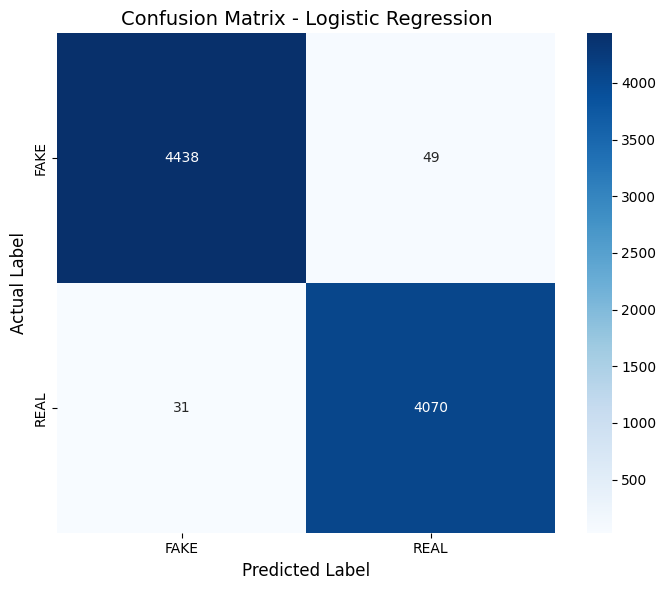

Confusion matrix plot saved: confusion_matrix_plot.png


In [10]:
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_plot.png', dpi=300)
plt.show()
print("Confusion matrix plot saved: confusion_matrix_plot.png")

In [11]:
print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['FAKE', 'REAL']))

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print(f"\nSpecificity (True Negative Rate): {specificity:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"False Negative Rate: {fnr:.4f}")

with open('confusion_matrix_metrics.txt', 'w') as f:
    f.write("CONFUSION MATRIX METRICS\n")
    f.write("=" * 50 + "\n")
    f.write(f"True Positives (TP): {tp}\n")
    f.write(f"True Negatives (TN): {tn}\n")
    f.write(f"False Positives (FP): {fp}\n")
    f.write(f"False Negatives (FN): {fn}\n")
    f.write("\n")
    f.write(f"Accuracy:  { (tp+tn)/(tp+tn+fp+fn):.4f}\n")
    f.write(f"Precision: { tp/(tp+fp):.4f}\n")
    f.write(f"Recall:    { tp/(tp+fn):.4f}\n")
    f.write(f"F1-Score:  { 2*tp/(2*tp+fp+fn):.4f}\n")
    f.write(f"Specificity: { specificity:.4f}\n")

print("\nMetrics saved: confusion_matrix_metrics.txt")
print("\nConfusion Matrix complete!")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99      4487
        REAL       0.99      0.99      0.99      4101

    accuracy                           0.99      8588
   macro avg       0.99      0.99      0.99      8588
weighted avg       0.99      0.99      0.99      8588


Specificity (True Negative Rate): 0.9891
False Positive Rate: 0.0109
False Negative Rate: 0.0076

Metrics saved: confusion_matrix_metrics.txt

Confusion Matrix complete!


In [12]:
print("\n" + "=" * 50)
print("COMPLETE PIPELINE FINISHED!")
print("=" * 50)


COMPLETE PIPELINE FINISHED!
